In [4]:
# Import general data processing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import NLP and ML libraries
import torch
from datasets import load_dataset
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification,
    TrainingArguments, 
    Trainer
)
import nltk
from nltk.tokenize import sent_tokenize
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# For visualization
import plotly.express as px
import plotly.graph_objects as go

# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

In [5]:
# Load CNN/Daily Mail dataset
# We'll use a small subset to start with for faster processing
try:
    cnn_dailymail = load_dataset("cnn_dailymail", "3.0.0", split="train[:1000]")
    print(f"Successfully loaded CNN/Daily Mail dataset with {len(cnn_dailymail)} samples")
    
    # Display a sample article
    print("\nSample article:")
    print(f"Article: {cnn_dailymail[0]['article'][:500]}...")
    print(f"Highlights: {cnn_dailymail[0]['highlights']}")
except Exception as e:
    print(f"Error loading CNN/Daily Mail dataset: {e}")

Successfully loaded CNN/Daily Mail dataset with 1000 samples

Sample article:
Article: LONDON, England (Reuters) -- Harry Potter star Daniel Radcliffe gains access to a reported £20 million ($41.1 million) fortune as he turns 18 on Monday, but he insists the money won't cast a spell on him. Daniel Radcliffe as Harry Potter in "Harry Potter and the Order of the Phoenix" To the disappointment of gossip columnists around the world, the young actor says he has no plans to fritter his cash away on fast cars, drink and celebrity parties. "I don't plan to be one of those people who, as s...
Highlights: Harry Potter star Daniel Radcliffe gets £20M fortune as he turns 18 Monday .
Young actor says he has no plans to fritter his cash away .
Radcliffe's earnings from first five Potter films have been held in trust fund .


In [6]:
# Load GoEmotions dataset
try:
    go_emotions = load_dataset("go_emotions", split="train")
    print(f"Successfully loaded GoEmotions dataset with {len(go_emotions)} samples")
    
    # Display a sample
    print("\nSample emotions data:")
    print(f"Text: {go_emotions[0]['text']}")
    print(f"Emotion IDs: {go_emotions[0]['labels']}")
    
    # Get emotion labels mapping
    emotions_mapping = go_emotions.features['labels'].feature.names
    print(f"\nEmotion labels mapping: {emotions_mapping}")
except Exception as e:
    print(f"Error loading GoEmotions dataset: {e}")

Successfully loaded GoEmotions dataset with 43410 samples

Sample emotions data:
Text: My favourite food is anything I didn't have to cook myself.
Emotion IDs: [27]

Emotion labels mapping: ['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']


CNN/Daily Mail Dataset Structure:
{'article': Value(dtype='string', id=None), 'highlights': Value(dtype='string', id=None), 'id': Value(dtype='string', id=None)}
Number of samples: 1000

GoEmotions Dataset Structure:
{'text': Value(dtype='string', id=None), 'labels': Sequence(feature=ClassLabel(names=['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral'], id=None), length=-1, id=None), 'id': Value(dtype='string', id=None)}
Number of samples: 43410

Emotion distribution in GoEmotions dataset:
       Emotion  Count
0      neutral  14219
1   admiration   4130
2     approval   2939
3    gratitude   2662
4    annoyance   2470
5    amusement   2328
6    curiosity   2191
7         love   2086
8  disapproval   2022
9   

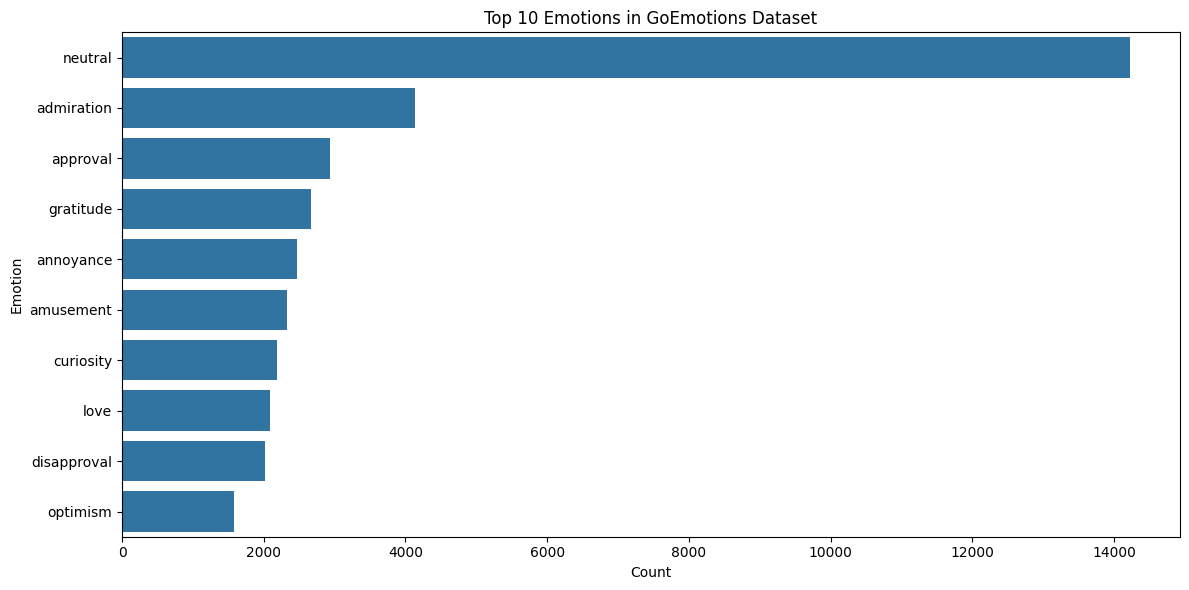

In [7]:
# Explore CNN/Daily Mail dataset
print("CNN/Daily Mail Dataset Structure:")
print(cnn_dailymail.features)
print(f"Number of samples: {len(cnn_dailymail)}")

# Explore GoEmotions dataset
print("\nGoEmotions Dataset Structure:")
print(go_emotions.features)
print(f"Number of samples: {len(go_emotions)}")

# Count the number of samples per emotion label in GoEmotions
emotion_counts = {}
for sample in go_emotions:
    for label in sample['labels']:
        emotion = emotions_mapping[label]
        if emotion in emotion_counts:
            emotion_counts[emotion] += 1
        else:
            emotion_counts[emotion] = 1

# Convert to DataFrame for easier analysis
emotion_df = pd.DataFrame(list(emotion_counts.items()), columns=['Emotion', 'Count'])
emotion_df = emotion_df.sort_values('Count', ascending=False).reset_index(drop=True)

print("\nEmotion distribution in GoEmotions dataset:")
print(emotion_df.head(10))

# Visualize emotion distribution
plt.figure(figsize=(12, 6))
sns.barplot(x='Count', y='Emotion', data=emotion_df.head(10))
plt.title('Top 10 Emotions in GoEmotions Dataset')
plt.tight_layout()
plt.show()

In [8]:
# Define preprocessing function for CNN/Daily Mail articles
def preprocess_article(article):
    # Download NLTK resources if needed
    try:
        nltk.data.find('tokenizers/punkt')
    except LookupError:
        nltk.download('punkt')
        
    try:
        nltk.data.find('corpora/stopwords')
    except LookupError:
        nltk.download('stopwords')
    
    # Split article into sentences
    sentences = sent_tokenize(article)
    
    # Basic cleaning
    cleaned_sentences = []
    for sentence in sentences:
        # Replace multiple spaces with a single space
        sentence = ' '.join(sentence.split())
        # Remove very short sentences (likely noise)
        if len(sentence.split()) > 3:
            cleaned_sentences.append(sentence)
    
    return cleaned_sentences

# Process a subset of articles
num_articles_to_process = 100
processed_articles = []

for i in range(min(num_articles_to_process, len(cnn_dailymail))):
    article = cnn_dailymail[i]['article']
    processed = preprocess_article(article)
    processed_articles.append({
        'id': i,
        'sentences': processed,
        'highlights': cnn_dailymail[i]['highlights']
    })

print(f"Processed {len(processed_articles)} articles")
print(f"Example of processed article: {len(processed_articles[0]['sentences'])} sentences")
print(f"First 3 sentences: {processed_articles[0]['sentences'][:3]}")

Processed 100 articles
Example of processed article: 23 sentences
First 3 sentences: ["LONDON, England (Reuters) -- Harry Potter star Daniel Radcliffe gains access to a reported £20 million ($41.1 million) fortune as he turns 18 on Monday, but he insists the money won't cast a spell on him.", 'Daniel Radcliffe as Harry Potter in "Harry Potter and the Order of the Phoenix" To the disappointment of gossip columnists around the world, the young actor says he has no plans to fritter his cash away on fast cars, drink and celebrity parties.', '"I don\'t plan to be one of those people who, as soon as they turn 18, suddenly buy themselves a massive sports car collection or something similar," he told an Australian interviewer earlier this month.']


In [9]:
# Preprocess GoEmotions dataset
def preprocess_go_emotions():
    # Create a simplified dataframe from the GoEmotions dataset
    data = []
    for sample in go_emotions:
        # Extract text and emotions
        text = sample['text']
        emotion_ids = sample['labels']
        
        # Skip samples with no emotions
        if len(emotion_ids) == 0:
            continue
        
        # Map IDs to emotion names
        emotions = [emotions_mapping[eid] for eid in emotion_ids]
        
        # For multi-label samples, we'll include them multiple times (once for each label)
        for emotion in emotions:
            data.append({
                'text': text,
                'emotion': emotion
            })
    
    # Convert to DataFrame
    df = pd.DataFrame(data)
    
    return df

go_emotions_df = preprocess_go_emotions()

print(f"Processed GoEmotions dataset shape: {go_emotions_df.shape}")
print(go_emotions_df.head())

# Check distribution of emotions
emotion_distribution = go_emotions_df['emotion'].value_counts()
print("\nEmotion distribution:")
print(emotion_distribution.head(10))

Processed GoEmotions dataset shape: (51103, 2)
                                                text    emotion
0  My favourite food is anything I didn't have to...    neutral
1  Now if he does off himself, everyone will thin...    neutral
2                     WHY THE FUCK IS BAYLESS ISOING      anger
3                        To make her feel threatened       fear
4                             Dirty Southern Wankers  annoyance

Emotion distribution:
emotion
neutral        14219
admiration      4130
approval        2939
gratitude       2662
annoyance       2470
amusement       2328
curiosity       2191
love            2086
disapproval     2022
optimism        1581
Name: count, dtype: int64


Grouped emotion distribution:
emotion_group
joy         18295
neutral     14219
anger        6059
other        4222
surprise     3538
sadness      3217
disgust       793
fear          760
Name: count, dtype: int64


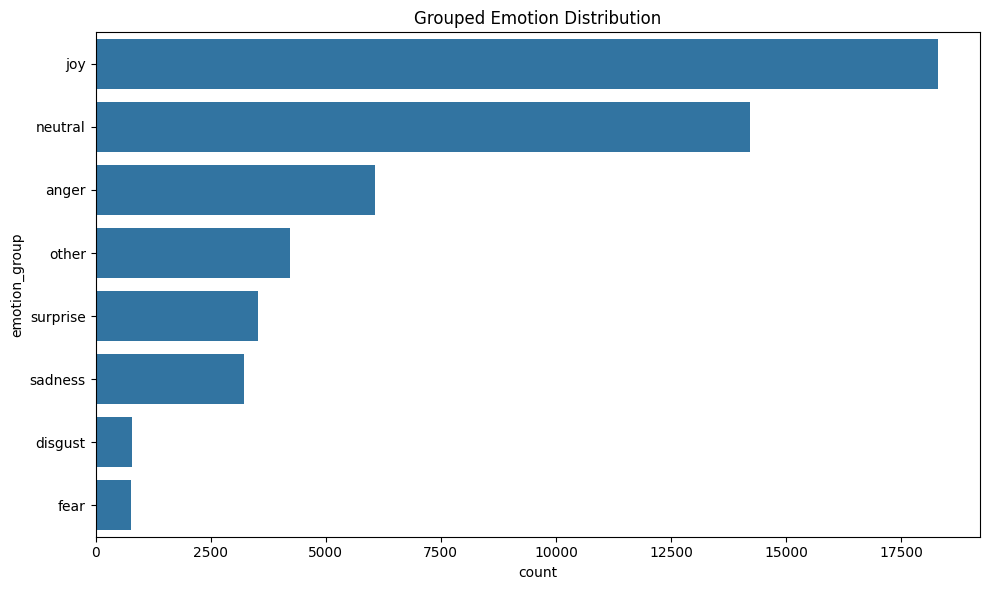

In [10]:
# Define emotion categories (group fine-grained emotions into broader categories)
emotion_groupings = {
    'joy': ['joy', 'amusement', 'approval', 'excitement', 'gratitude', 'love', 'optimism', 'relief', 'pride', 'admiration'],
    'anger': ['anger', 'annoyance', 'disapproval'],
    'sadness': ['sadness', 'disappointment', 'grief', 'remorse'],
    'fear': ['fear', 'nervousness'],
    'surprise': ['surprise', 'realization', 'confusion'],
    'disgust': ['disgust'],
    'neutral': ['neutral'],
    'other': ['curiosity', 'desire', 'embarrassment', 'caring']
}

# Create a mapping from detailed emotions to grouped categories
emotion_to_group = {}
for group, emotions in emotion_groupings.items():
    for emotion in emotions:
        emotion_to_group[emotion] = group

# Map emotions to groups in our dataset
go_emotions_df['emotion_group'] = go_emotions_df['emotion'].map(emotion_to_group)

# Check distribution of grouped emotions
group_distribution = go_emotions_df['emotion_group'].value_counts()
print("Grouped emotion distribution:")
print(group_distribution)

# Visualize grouped emotions
plt.figure(figsize=(10, 6))
sns.countplot(y='emotion_group', data=go_emotions_df, order=group_distribution.index)
plt.title('Grouped Emotion Distribution')
plt.tight_layout()
plt.show()

In [11]:
# Install needed libraries if necessary
# !pip install scikit-learn tensorflow keras sentence-transformers

# Additional imports for model building and evaluation
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, LSTM, Bidirectional, Conv1D, MaxPooling1D, GlobalMaxPooling1D, SimpleRNN
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Ensure TensorFlow uses GPU if available
print("GPU is", "available" if tf.config.list_physical_devices('GPU') else "NOT available")

# Set maximum sequence length and vocabulary size for text processing
MAX_SEQUENCE_LENGTH = 100
MAX_VOCAB_SIZE = 10000

GPU is NOT available


In [12]:
# Prepare data for modeling
# Select data with balanced emotion groups
grouped_emotions_df = go_emotions_df[['text', 'emotion_group']].copy()

# Use only the most common emotions to ensure enough training data
top_emotions = group_distribution.index[:7]  # Exclude 'other' if it has too few samples
filtered_emotions_df = grouped_emotions_df[grouped_emotions_df['emotion_group'].isin(top_emotions)]

# Display the resulting dataset
print(f"Filtered dataset shape: {filtered_emotions_df.shape}")
print(f"Emotion distribution after filtering:")
print(filtered_emotions_df['emotion_group'].value_counts())

# Encode emotion labels
label_encoder = LabelEncoder()
filtered_emotions_df['emotion_encoded'] = label_encoder.fit_transform(filtered_emotions_df['emotion_group'])

# Show encoding mapping
for i, emotion in enumerate(label_encoder.classes_):
    print(f"{emotion}: {i}")

# Split data into train, validation, and test sets
X = filtered_emotions_df['text'].values
y = filtered_emotions_df['emotion_encoded'].values

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Tokenize and pad sequences for traditional models
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_SEQUENCE_LENGTH)
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_SEQUENCE_LENGTH)
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_SEQUENCE_LENGTH)

# Convert to categorical for model training
y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes=len(top_emotions))
y_val_cat = tf.keras.utils.to_categorical(y_val, num_classes=len(top_emotions))
y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes=len(top_emotions))

vocab_size = min(MAX_VOCAB_SIZE, len(tokenizer.word_index) + 1)
print(f"Vocabulary size: {vocab_size}")

Filtered dataset shape: (50343, 2)
Emotion distribution after filtering:
emotion_group
joy         18295
neutral     14219
anger        6059
other        4222
surprise     3538
sadness      3217
disgust       793
Name: count, dtype: int64
anger: 0
disgust: 1
joy: 2
neutral: 3
other: 4
sadness: 5
surprise: 6
Training set: 30205 samples
Validation set: 10069 samples
Test set: 10069 samples


C:\Users\G15\AppData\Local\Temp\ipykernel_21700\2616363476.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_emotions_df['emotion_encoded'] = label_encoder.fit_transform(filtered_emotions_df['emotion_group'])


Vocabulary size: 10000


In [27]:
# Define models for comparison
def build_cnn_model(vocab_size, embedding_dim, input_length, num_classes):
    model = Sequential()
    model.add(Embedding(vocab_size, embedding_dim, input_length=input_length))
    model.add(Conv1D(128, 5, activation='relu'))
    model.add(GlobalMaxPooling1D())
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(num_classes, activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

def build_rnn_model(vocab_size, embedding_dim, input_length, num_classes):
    model = Sequential()
    model.add(Embedding(vocab_size, embedding_dim, input_length=input_length))
    model.add(SimpleRNN(128, return_sequences=False))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(num_classes, activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

def build_lstm_model(vocab_size, embedding_dim, input_length, num_classes):
    model = Sequential()
    model.add(Embedding(vocab_size, embedding_dim, input_length=input_length))
    model.add(LSTM(128, return_sequences=False))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(num_classes, activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

def build_cnn_lstm_model(vocab_size, embedding_dim, input_length, num_classes):
    model = Sequential()
    model.add(Embedding(vocab_size, embedding_dim, input_length=input_length))
    model.add(Conv1D(128, 5, activation='relu'))
    model.add(MaxPooling1D(5))
    model.add(LSTM(128))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(num_classes, activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [29]:
# Define a function for training models and evaluating performance
def train_and_evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_test, batch_size=32, epochs=5):
    # Train the model
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=1
    )
    
    # Evaluate on test set
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_test_decoded = np.argmax(y_test, axis=1)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test_decoded, y_pred)
    precision = precision_score(y_test_decoded, y_pred, average='weighted')
    recall = recall_score(y_test_decoded, y_pred, average='weighted')
    f1 = f1_score(y_test_decoded, y_pred, average='weighted')
    
    # Print classification report
    print("\nClassification Report:")
    report = classification_report(y_test_decoded, y_pred, target_names=label_encoder.classes_, digits=4)
    print(report)
    
    return {
        'model': model,
        'history': history,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'y_pred': y_pred,
        'report': report
    }

# Define parameters
embedding_dim = 100
num_classes = len(top_emotions)
epochs = 3  # Using few epochs for demonstration
batch_size = 32

# Dictionary to store results
model_results = {}

# Train and evaluate CNN model
print("\n====== Training CNN Model ======")
cnn_model = build_cnn_model(vocab_size, embedding_dim, MAX_SEQUENCE_LENGTH, num_classes)
model_results['CNN'] = train_and_evaluate_model(
    cnn_model, X_train_pad, y_train_cat, X_val_pad, y_val_cat, X_test_pad, y_test_cat,
    batch_size=batch_size, epochs=epochs
)

# Train and evaluate RNN model
print("\n====== Training RNN Model ======")
rnn_model = build_rnn_model(vocab_size, embedding_dim, MAX_SEQUENCE_LENGTH, num_classes)
model_results['RNN'] = train_and_evaluate_model(
    rnn_model, X_train_pad, y_train_cat, X_val_pad, y_val_cat, X_test_pad, y_test_cat,
    batch_size=batch_size, epochs=epochs
)

# Train and evaluate LSTM model
print("\n====== Training LSTM Model ======")
lstm_model = build_lstm_model(vocab_size, embedding_dim, MAX_SEQUENCE_LENGTH, num_classes)
model_results['LSTM'] = train_and_evaluate_model(
    lstm_model, X_train_pad, y_train_cat, X_val_pad, y_val_cat, X_test_pad, y_test_cat,
    batch_size=batch_size, epochs=epochs
)

# Train and evaluate CNN-LSTM model
print("\n====== Training CNN-LSTM Model ======")
cnn_lstm_model = build_cnn_lstm_model(vocab_size, embedding_dim, MAX_SEQUENCE_LENGTH, num_classes)
model_results['CNN-LSTM'] = train_and_evaluate_model(
    cnn_lstm_model, X_train_pad, y_train_cat, X_val_pad, y_val_cat, X_test_pad, y_test_cat,
    batch_size=batch_size, epochs=epochs
)


====== Training CNN Model ======
Epoch 1/3


c:\Users\G15\Desktop\coding\.conda\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


944/944 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.4613 - loss: 1.4811 - val_accuracy: 0.5942 - val_loss: 1.1516
Epoch 2/3
944/944 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6292 - loss: 1.0580 - val_accuracy: 0.5998 - val_loss: 1.1159
Epoch 3/3
404/944 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7253 - loss: 0.7913

KeyboardInterrupt: 

In [23]:
# For S-BERT model - optimized implementation for research
from sentence_transformers import SentenceTransformer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.svm import LinearSVC
import numpy as np
from tqdm.notebook import tqdm

print("\n====== Training S-BERT-based Model ======")

# Load pre-trained Sentence-BERT model
sbert_model = SentenceTransformer('paraphrase-MiniLM-L6-v2')

# Function to generate embeddings with batching
def generate_sbert_embeddings(texts, model, batch_size=32):
    all_embeddings = []
    
    for i in tqdm(range(0, len(texts), batch_size), desc="Generating embeddings"):
        batch_texts = texts[i:i+batch_size]
        batch_embeddings = model.encode(batch_texts)
        all_embeddings.append(batch_embeddings)
    
    return np.vstack(all_embeddings)

# Generate embeddings for full training set
print(f"Generating S-BERT embeddings for {len(X_train)} training samples...")
X_train_sbert = generate_sbert_embeddings(X_train, sbert_model)

# Train SVM classifier with grid search for optimal parameters
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grid
param_grid = {
    'C': [0.1, 1, 10],
    'class_weight': ['balanced', None],
}

# Set up SVM with grid search
svm = LinearSVC(random_state=42)
grid_search = GridSearchCV(
    svm, param_grid, cv=3, 
    scoring='f1_weighted', n_jobs=-1, verbose=1
)

# Train the model with grid search
print("Training S-BERT classifier with hyperparameter tuning...")
grid_search.fit(X_train_sbert, y_train)

# Get best model
sbert_classifier = grid_search.best_estimator_
print(f"Best parameters: {grid_search.best_params_}")

# Generate embeddings for validation set
print(f"Generating S-BERT embeddings for {len(X_val)} validation samples...")
X_val_sbert = generate_sbert_embeddings(X_val, sbert_model)

# Evaluate on validation set
y_val_pred = sbert_classifier.predict(X_val_sbert)
val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred, average='weighted')
val_recall = recall_score(y_val, y_val_pred, average='weighted')
val_f1 = f1_score(y_val, y_val_pred, average='weighted')

print(f"\nS-BERT with SVC Validation Metrics:")
print(f"Accuracy: {val_accuracy:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall: {val_recall:.4f}")
print(f"F1 Score: {val_f1:.4f}")

# Generate embeddings for test set
print(f"Generating S-BERT embeddings for {len(X_test)} test samples...")
X_test_sbert = generate_sbert_embeddings(X_test, sbert_model)

# Evaluate on test set
y_test_pred = sbert_classifier.predict(X_test_sbert)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='weighted')
test_recall = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

print(f"\nS-BERT with SVC Test Metrics:")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1 Score: {test_f1:.4f}")

# Print classification report
print("\nClassification Report:")
report = classification_report(y_test, y_test_pred, 
                              target_names=label_encoder.classes_,
                              digits=4)
print(report)

model_results['S-BERT'] = {
    'accuracy': test_accuracy,
    'precision': test_precision,
    'recall': test_recall,
    'f1_score': test_f1,
    'classifier': sbert_classifier,
    'encoder': sbert_model,
    'report': report
}


====== Training S-BERT-based Model ======
Generating S-BERT embeddings for 30205 training samples...


Generating embeddings:   0%|          | 0/944 [00:00<?, ?it/s]

Training S-BERT classifier with hyperparameter tuning...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best parameters: {'C': 0.1, 'class_weight': 'balanced'}
Generating S-BERT embeddings for 10069 validation samples...


Generating embeddings:   0%|          | 0/315 [00:00<?, ?it/s]


S-BERT with SVC Validation Metrics:
Accuracy: 0.5194
Precision: 0.5547
Recall: 0.5194
F1 Score: 0.5307
Generating S-BERT embeddings for 10069 test samples...


Generating embeddings:   0%|          | 0/315 [00:00<?, ?it/s]


S-BERT with SVC Test Metrics:
Accuracy: 0.5143
Precision: 0.5505
Recall: 0.5143
F1 Score: 0.5258

Classification Report:
              precision    recall  f1-score   support

       anger     0.3925    0.4290    0.4099      1212
     disgust     0.1231    0.4591    0.1941       159
         joy     0.7581    0.6988    0.7272      3659
     neutral     0.5644    0.4269    0.4861      2844
       other     0.3019    0.2808    0.2910       844
     sadness     0.3399    0.5645    0.4243       643
    surprise     0.2765    0.3023    0.2888       708

    accuracy                         0.5143     10069
   macro avg     0.3938    0.4516    0.4031     10069
weighted avg     0.5505    0.5143    0.5258     10069




Model Performance Comparison:
          accuracy precision    recall  f1_score
CNN       0.522296  0.531977  0.522296  0.525679
RNN       0.493098  0.476776  0.493098  0.482797
LSTM      0.517132  0.507815  0.517132  0.511942
CNN-LSTM  0.475916  0.476687  0.475916   0.47527
S-BERT    0.514252  0.550528  0.514252  0.525774


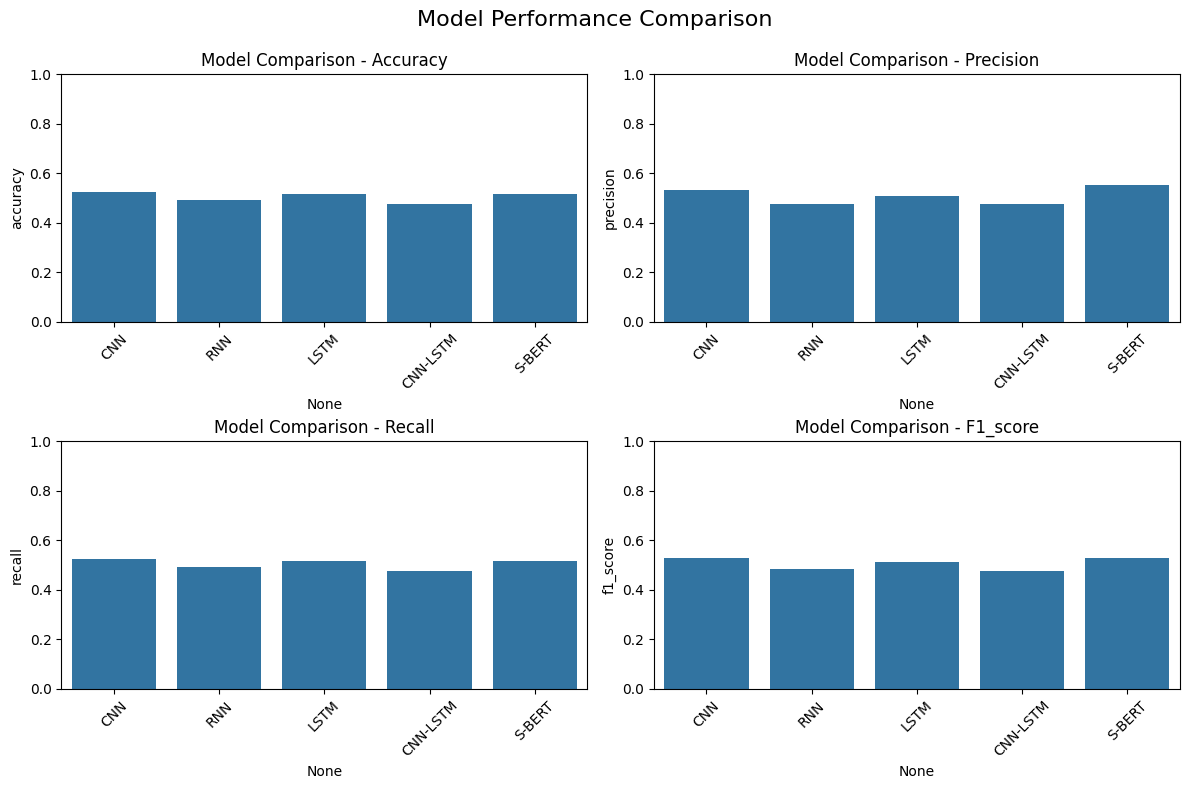


Best performing model based on F1-Score: S-BERT
F1-Score: 0.5258


In [24]:
# Compare model performance
metrics = ['accuracy', 'precision', 'recall', 'f1_score']
comparison_df = pd.DataFrame(index=model_results.keys(), columns=metrics)

for model_name, result in model_results.items():
    for metric in metrics:
        comparison_df.loc[model_name, metric] = result[metric]

# Display comparison
print("\nModel Performance Comparison:")
print(comparison_df)

# Visualize comparison
plt.figure(figsize=(12, 8))
for i, metric in enumerate(metrics):
    plt.subplot(2, 2, i+1)
    sns.barplot(x=comparison_df.index, y=comparison_df[metric])
    plt.title(f'Model Comparison - {metric.capitalize()}')
    plt.ylim(0, 1.0)
    plt.xticks(rotation=45)
    plt.tight_layout()

plt.suptitle('Model Performance Comparison', fontsize=16)
plt.subplots_adjust(top=0.9)
plt.show()

# Identify best model
best_model_name = comparison_df['f1_score'].idxmax()
print(f"\nBest performing model based on F1-Score: {best_model_name}")
print(f"F1-Score: {comparison_df.loc[best_model_name, 'f1_score']:.4f}")

Average F1-score by emotion across all models:
joy        0.70096
neutral    0.49530
sadness    0.39724
anger      0.37300
other      0.22486
disgust    0.20168
Name: Average, dtype: float64


<Figure size 1400x800 with 0 Axes>

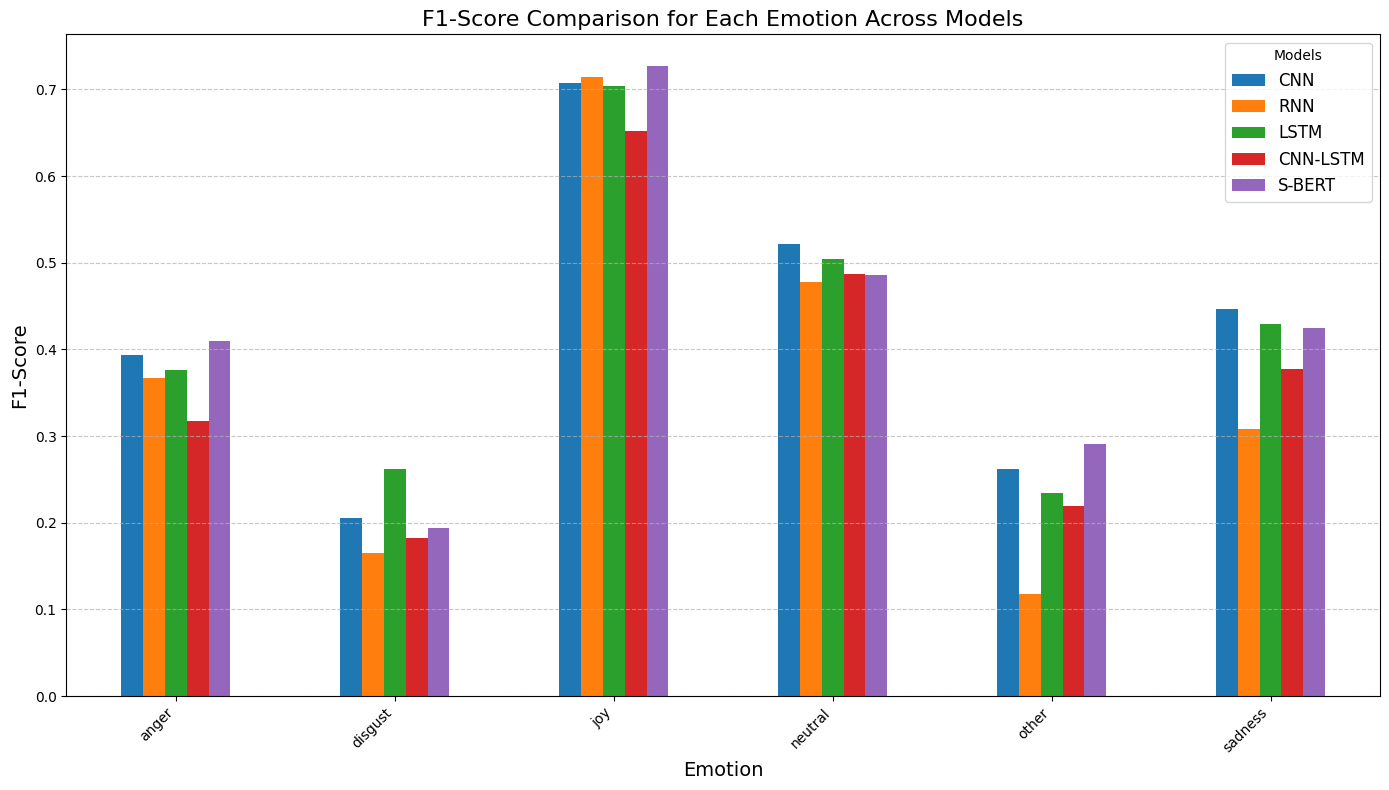

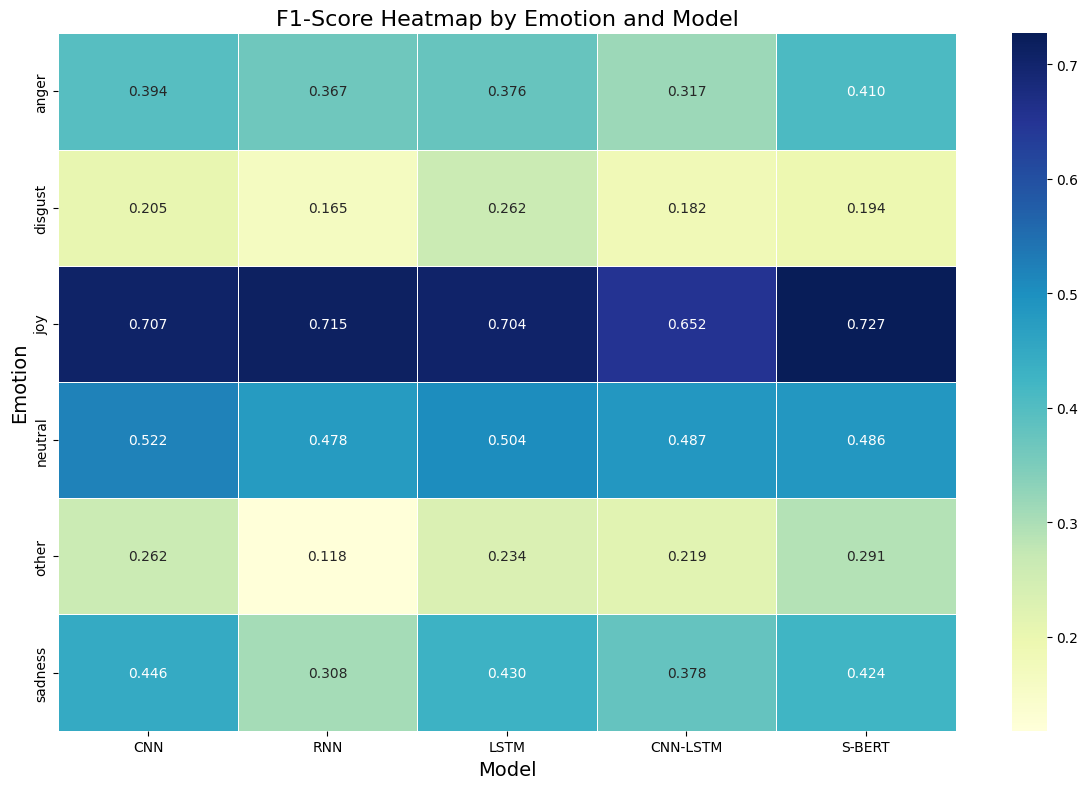

In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report

# Create a dataframe to store F1-scores for each model and emotion
import matplotlib.pyplot as plt

# Extract F1-scores for each emotion from classification reports
emotion_f1_scores = {}

for model_name, result in model_results.items():
    if 'report' in result:
        # Parse the classification report
        lines = result['report'].strip().split('\n')
        emotion_scores = {}
        
        # Extract emotion specific scores
        for i, line in enumerate(lines):
            if i > 0 and i < len(label_encoder.classes_) + 1:  # Skip header and summary rows
                parts = line.split()
                if len(parts) >= 4:  # Ensure we have enough parts
                    emotion = parts[0]
                    f1_score = float(parts[3])
                    emotion_scores[emotion] = f1_score
        
        emotion_f1_scores[model_name] = emotion_scores

# Convert to dataframe for visualization
f1_df = pd.DataFrame(emotion_f1_scores)

# Plot F1-scores for each emotion across models
plt.figure(figsize=(14, 8))
f1_df.plot(kind='bar', figsize=(14, 8))
plt.title('F1-Score Comparison for Each Emotion Across Models', fontsize=16)
plt.xlabel('Emotion', fontsize=14)
plt.ylabel('F1-Score', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Models', fontsize=12)
plt.tight_layout()

# Add a heatmap for easier comparison
plt.figure(figsize=(12, 8))
sns.heatmap(f1_df, annot=True, cmap='YlGnBu', fmt='.3f', linewidths=.5)
plt.title('F1-Score Heatmap by Emotion and Model', fontsize=16)
plt.ylabel('Emotion', fontsize=14)
plt.xlabel('Model', fontsize=14)
plt.tight_layout()

# Calculate and display the average F1-score by emotion
f1_df['Average'] = f1_df.mean(axis=1)
print("Average F1-score by emotion across all models:")
print(f1_df['Average'].sort_values(ascending=False))

plt.show()

In [17]:
# Implement the Emotion-Aware Document Retrieval System
# Prepare CNN/Daily Mail documents for retrieval
print("\nPreparing documents for retrieval...")

# Create a single text document from each article
documents = []
for i, article in enumerate(processed_articles):
    # Join sentences to create a single document text
    doc_text = " ".join(article['sentences'])
    documents.append({
        'id': article['id'],
        'text': doc_text,
        'highlights': article['highlights']
    })

print(f"Prepared {len(documents)} documents for retrieval")

# Use S-BERT for document embedding
try:
    # Load S-BERT model if it wasn't already loaded
    if 'S-BERT' not in model_results or 'encoder' not in model_results['S-BERT']:
        sbert_model = SentenceTransformer('paraphrase-MiniLM-L6-v2')
    else:
        sbert_model = model_results['S-BERT']['encoder']
    
    # Generate embeddings for all documents
    print("Generating document embeddings...")
    doc_texts = [doc['text'] for doc in documents]
    doc_embeddings = sbert_model.encode(doc_texts)
    
    # Add embeddings to document objects
    for i, embedding in enumerate(doc_embeddings):
        documents[i]['embedding'] = embedding
    
    # Get the emotion classifier (use the best model from comparison)
    if best_model_name == 'S-BERT' and 'classifier' in model_results['S-BERT']:
        emotion_classifier = model_results['S-BERT']['classifier']
    else:
        # Use S-BERT + SVC classifier as default if the best model is not available
        emotion_classifier = model_results.get('S-BERT', {}).get('classifier')
    
    # If we have a valid classifier, extract emotions from documents
    if emotion_classifier is not None:
        print("Extracting emotions from documents...")
        # Get emotion embeddings
        doc_emotion_embeddings = sbert_model.encode(doc_texts)
        # Predict emotions
        doc_emotions = emotion_classifier.predict(doc_emotion_embeddings)
        
        # Add emotion to document objects
        for i, emotion_id in enumerate(doc_emotions):
            documents[i]['emotion'] = emotion_id
            documents[i]['emotion_name'] = label_encoder.classes_[emotion_id]
        
        print("Documents with emotions:")
        emotion_counts = {}
        for doc in documents:
            emotion = doc['emotion_name']
            if emotion in emotion_counts:
                emotion_counts[emotion] += 1
            else:
                emotion_counts[emotion] = 1
        
        for emotion, count in emotion_counts.items():
            print(f"- {emotion}: {count} documents")
    
except Exception as e:
    print(f"Error in document embedding/emotion extraction: {e}")


Preparing documents for retrieval...
Prepared 100 documents for retrieval
Generating document embeddings...
Extracting emotions from documents...
Documents with emotions:
- neutral: 40 documents
- joy: 30 documents
- anger: 7 documents
- other: 20 documents
- sadness: 1 documents
- surprise: 2 documents


In [18]:
# Implement the Emotion-Aware Retrieval System
class EmotionAwareRetriever:
    def __init__(self, documents, encoder, emotion_classifier=None, label_encoder=None):
        self.documents = documents
        self.encoder = encoder
        self.emotion_classifier = emotion_classifier
        self.label_encoder = label_encoder
        
        # Pre-compute document embeddings if they don't exist
        for i, doc in enumerate(self.documents):
            if 'embedding' not in doc:
                self.documents[i]['embedding'] = encoder.encode(doc['text'])
        
        # Stack document embeddings for efficient similarity computation
        self.doc_embeddings = np.vstack([doc['embedding'] for doc in self.documents])
        
    def extract_emotion(self, text):
        """Extract emotion from text using the classifier"""
        if self.emotion_classifier is None:
            return None
        
        # Get embedding and predict emotion
        embedding = self.encoder.encode([text])[0].reshape(1, -1)
        emotion_id = self.emotion_classifier.predict(embedding)[0]
        
        # Map to emotion name if label encoder is available
        if self.label_encoder is not None:
            emotion_name = self.label_encoder.classes_[emotion_id]
            return emotion_id, emotion_name
        
        return emotion_id, None
        
    def search(self, query, top_k=5, emotion_weight=0.3, target_emotion=None):
        """
        Search documents based on query similarity and emotion matching
        
        Parameters:
        - query: text query
        - top_k: number of documents to retrieve
        - emotion_weight: weight for emotion similarity (0-1)
        - target_emotion: specific emotion to boost in results (emotion_id or name)
        
        Returns:
        - List of document results with similarity scores
        """
        # Get query embedding
        query_embedding = self.encoder.encode([query])[0].reshape(1, -1)
        
        # Calculate semantic similarity
        semantic_scores = cosine_similarity(query_embedding, self.doc_embeddings)[0]
        
        # If we want emotion-aware retrieval and have a classifier
        if emotion_weight > 0 and self.emotion_classifier is not None:
            # Extract emotion from query
            query_emotion_id, query_emotion_name = self.extract_emotion(query)
            
            # Use target_emotion if provided, otherwise use query's emotion
            if target_emotion is not None:
                # Convert emotion name to ID if needed
                if isinstance(target_emotion, str) and self.label_encoder is not None:
                    for i, name in enumerate(self.label_encoder.classes_):
                        if name == target_emotion:
                            target_emotion = i
                            break
                query_emotion_id = target_emotion
            
            print(f"Query emotion: {query_emotion_name} (ID: {query_emotion_id})")
            
            # Calculate emotion similarity (1 if same emotion, 0 otherwise)
            emotion_scores = np.zeros(len(self.documents))
            for i, doc in enumerate(self.documents):
                doc_emotion = doc.get('emotion')
                if doc_emotion == query_emotion_id:
                    emotion_scores[i] = 1.0
            
            # Combine scores
            combined_scores = (1 - emotion_weight) * semantic_scores + emotion_weight * emotion_scores
        else:
            # Use only semantic similarity
            combined_scores = semantic_scores
        
        # Get top-k documents
        top_indices = np.argsort(combined_scores)[-top_k:][::-1]
        
        results = []
        for idx in top_indices:
            doc = self.documents[idx]
            results.append({
                'id': doc['id'],
                'text': doc['text'][:200] + "...",
                'highlights': doc['highlights'],
                'emotion': doc.get('emotion_name', 'Unknown'),
                'score': combined_scores[idx],
                'semantic_score': semantic_scores[idx],
                'emotion_score': emotion_scores[idx] if emotion_weight > 0 else 0,
            })
        
        return results

In [19]:
# Create an instance of the Emotion-Aware Retriever
try:
    retriever = EmotionAwareRetriever(
        documents=documents, 
        encoder=sbert_model, 
        emotion_classifier=model_results.get('S-BERT', {}).get('classifier'),
        label_encoder=label_encoder
    )
    
    # Demo search function
    def demo_search():
        print("\n===== EMOTION-AWARE DOCUMENT RETRIEVAL DEMO =====")
        
        while True:
            query = input("\nEnter your search query (or 'exit' to quit): ")
            
            if query.lower() == 'exit':
                break
            
            # Get emotion preference
            print("\nEmotions available:")
            for i, emotion in enumerate(label_encoder.classes_):
                print(f"{i}: {emotion}")
            
            emotion_input = input("\nSpecify target emotion (number or name, leave blank for auto-detection): ")
            
            # Parse emotion input
            target_emotion = None
            if emotion_input:
                try:
                    if emotion_input.isdigit():
                        target_emotion = int(emotion_input)
                    else:
                        target_emotion = emotion_input
                except:
                    print("Invalid emotion, using auto-detection")
            
            # Get emotion weight
            try:
                emotion_weight = float(input("\nEmotion weight (0.0-1.0, default=0.3): ") or 0.3)
                emotion_weight = max(0, min(1, emotion_weight))
            except:
                print("Invalid weight, using default (0.3)")
                emotion_weight = 0.3
            
            # Get number of results
            try:
                top_k = int(input("\nNumber of results to show (default=5): ") or 5)
            except:
                top_k = 5
            
            # Perform search
            results = retriever.search(
                query=query,
                top_k=top_k,
                emotion_weight=emotion_weight,
                target_emotion=target_emotion
            )
            
            # Display results
            print("\n===== SEARCH RESULTS =====")
            for i, result in enumerate(results):
                print(f"\n{i+1}. Document {result['id']}")
                print(f"   Emotion: {result['emotion']}")
                print(f"   Combined Score: {result['score']:.4f}")
                print(f"   Semantic Score: {result['semantic_score']:.4f}")
                print(f"   Emotion Score: {result['emotion_score']:.4f}")
                print(f"   Preview: {result['text']}")
                print(f"   Highlights: {result['highlights'][:100]}...")
                print("-" * 50)
    
    # Run the demo
    print("\nSearch system ready! You can now search documents with emotion awareness.")
    print("Uncomment and run the next line to start the interactive search demo")
    # demo_search()  # Uncomment to run the interactive demo
    
except Exception as e:
    print(f"Error initializing retrieval system: {e}")


Search system ready! You can now search documents with emotion awareness.
Uncomment and run the next line to start the interactive search demo


In [20]:
# Example of non-interactive search to demonstrate the system
def example_searches():
    """Run example searches to demonstrate the system"""
    print("\n===== EXAMPLE SEARCHES =====")
    
    # Example 1: Neutral search with no emotion weighting
    query1 = "international politics"
    print(f"\nExample 1: '{query1}' (No emotion weighting)")
    results1 = retriever.search(query1, emotion_weight=0.0)
    for i, result in enumerate(results1[:3]):  # Show only top 3 for brevity
        print(f"{i+1}. Doc {result['id']} ({result['emotion']}) - Score: {result['score']:.4f}")
        print(f"   Preview: {result['text'][:100]}...")
    
    # Example 2: Search with emotion weighting
    query2 = "tragic accident"
    print(f"\nExample 2: '{query2}' (With emotion weighting=0.5)")
    results2 = retriever.search(query2, emotion_weight=0.5)
    for i, result in enumerate(results2[:3]):
        print(f"{i+1}. Doc {result['id']} ({result['emotion']}) - Score: {result['score']:.4f}")
        print(f"   Preview: {result['text'][:100]}...")
    
    # Example 3: Search with specific target emotion
    query3 = "breaking news"
    target_emotion = "surprise"
    print(f"\nExample 3: '{query3}' (With target emotion='{target_emotion}')")
    results3 = retriever.search(query3, emotion_weight=0.7, target_emotion=target_emotion)
    for i, result in enumerate(results3[:3]):
        print(f"{i+1}. Doc {result['id']} ({result['emotion']}) - Score: {result['score']:.4f}")
        print(f"   Preview: {result['text'][:100]}...")

# Run example searches
try:
    example_searches()
except Exception as e:
    print(f"Error running example searches: {e}")

print("\n===== PROJECT COMPLETE =====")
print("You've successfully implemented an Emotion-Aware Semantic Document Retrieval system!")
print("The system uses S-BERT for embeddings and a trained emotion classifier to enhance retrieval.")
print("To use the interactive search, uncomment the demo_search() call in the previous cell.")


===== EXAMPLE SEARCHES =====

Example 1: 'international politics' (No emotion weighting)
1. Doc 36 (other) - Score: 0.4269
   Preview: WASHINGTON (CNN) -- Some Democrats appear to be wavering on a highly contentious House resolution la...
2. Doc 85 (neutral) - Score: 0.3840
   Preview: (CNN) -- This week MME speaks to the man charged with boosting growth in the Kingdom of Bahrain: She...
3. Doc 31 (neutral) - Score: 0.3753
   Preview: LONDON, England (CNN) -- French Foreign Minister Bernard Kouchner's declaration that France had to p...

Example 2: 'tragic accident' (With emotion weighting=0.5)
Query emotion: neutral (ID: 3)
1. Doc 43 (neutral) - Score: 0.6700
   Preview: BOLINGBROOK, Illinois (CNN) -- The disappearance of a suburban Chicago police sergeant's wife is now...
2. Doc 86 (neutral) - Score: 0.6672
   Preview: ALGIERS, Algeria (CNN) -- Rescuers are sifting through the rubble of the United Nations headquarters...
3. Doc 14 (neutral) - Score: 0.6627
   Preview: SAN FRANCISCO,